In [3]:
import pandas as pd
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncode
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('Market_Basket_Optimisation.csv', header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
trans=[]
for i in range(0,df.shape[0]):
    a=[str(item) for item in df.iloc[i] if str(item) !='nan']
    trans.append(a)
trans[:5]   

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [7]:

te = TransactionEncoder()
te_ary = te.fit(trans).transform(trans)
df = pd.DataFrame(te_ary, columns=te.columns_)

feqi = apriori(df,min_support=0.01 , use_colnames=True)

rules = association_rules(feqi,metric="confidence",min_threshold=0.2)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(avocado),(mineral water),0.033329,0.238368,0.011598,0.348000,1.459926,0.003654,1.168147,0.325896
1,(burgers),(eggs),0.087188,0.179709,0.028796,0.330275,1.837830,0.013128,1.224818,0.499424
2,(burgers),(french fries),0.087188,0.170911,0.021997,0.252294,1.476173,0.007096,1.108844,0.353384
3,(burgers),(green tea),0.087188,0.132116,0.017464,0.200306,1.516139,0.005945,1.085270,0.372947
4,(burgers),(milk),0.087188,0.129583,0.017864,0.204893,1.581175,0.006566,1.094717,0.402667


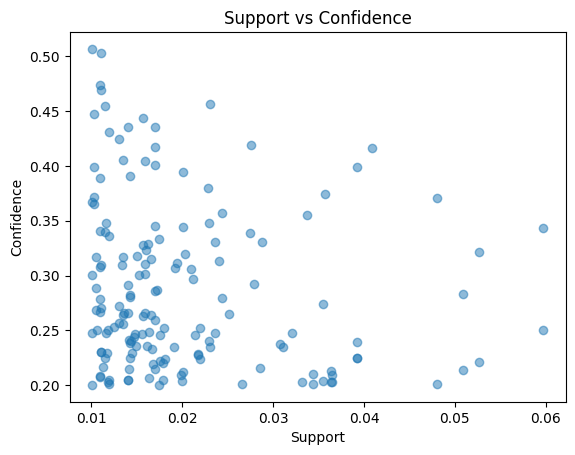

In [9]:
plt.scatter(rules['support'],rules['confidence'],alpha=0.5)
plt.title('Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

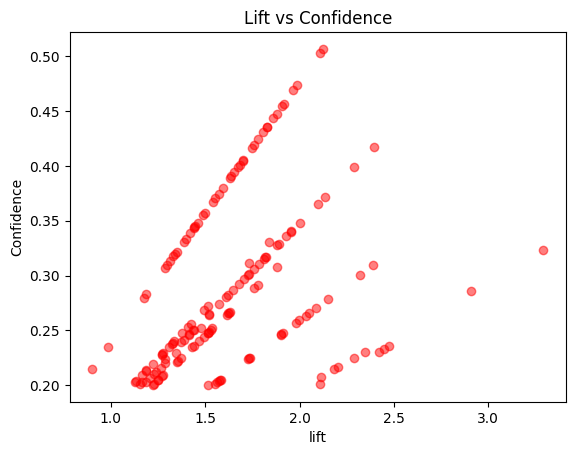

In [10]:
plt.scatter(rules['lift'],rules['confidence'] ,alpha = 0.5 , color='red')
plt.title('Lift vs Confidence')
plt.xlabel('lift')
plt.ylabel('Confidence')
plt.show()

In [12]:
rules_h_c = association_rules(feqi,metric="confidence",min_threshold=0.5)

rules_h_c.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(eggs, ground beef)",(mineral water),0.019997,0.238368,0.010132,0.506667,2.125563,0.005365,1.543848,0.540342
1,"(ground beef, milk)",(mineral water),0.021997,0.238368,0.011065,0.503030,2.110308,0.005822,1.532552,0.537969


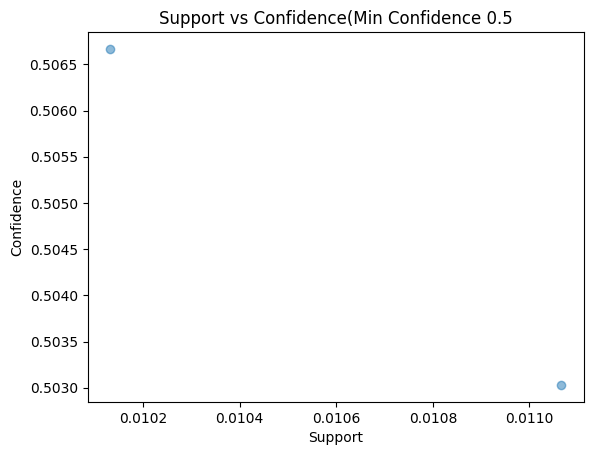

In [13]:
plt.scatter(rules_h_c['support'],rules_h_c['confidence'],alpha=0.5)
plt.title('Support vs Confidence(Min Confidence 0.5)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()